# User Training Results
Use this notebook to analyze your training results from VI-user-training.ipynb

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Get save file
file_path = "/pscratch/sd/q/qshimp/VI_training/savefiles/QuillanIMR.csv"

df = pd.read_csv(file_path)

df.head()

,timestamp,username,target_id,true_class,user_class,correct,response_time
0,2026-07-04T08:13:49,QuillanIMR,906953,S,E,False,31.701475
1,2026-07-04T08:13:57,QuillanIMR,738093,I,I,True,6.735874
2,2026-07-04T08:14:41,QuillanIMR,816299,E,E,True,43.377617
3,2026-07-04T08:14:47,QuillanIMR,1193471,L,L,True,6.438839
4,2026-07-04T08:14:50,QuillanIMR,453831,I,I,True,2.381979


In [3]:
# Enforce datatypes
df["correct"] = df["correct"].astype(bool)
df["response_time"] = df["response_time"].astype(float)

df["true_class"] = df["true_class"].astype(str)
df["user_class"] = df["user_class"].astype(str)

In [4]:
# General statistics
total = len(df)
accuracy = df["correct"].mean()

print(f"Total galaxies classified: {total}")
print(f"Accuracy: {accuracy*100:.2f}%")

Total galaxies classified: 297
Accuracy: 72.05%


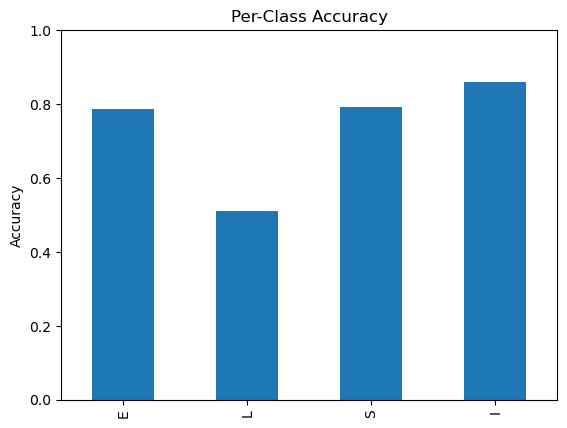

In [5]:
# Plot per-class accuracy
classes = ["E", "L", "S", "I"]

results = {}

for c in classes:
    subset = df[df["true_class"] == c]
    acc = subset["correct"].mean() if len(subset) > 0 else np.nan
    results[c] = acc

pd.Series(results).plot(kind="bar")
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.ylim(0, 1)
plt.show()

In [6]:
# Create cross table
conf = pd.crosstab(
    df["true_class"],
    df["user_class"]
).reindex(index=classes, columns=classes, fill_value=0)

conf

user_class,E,L,S,I
true_class,,,,
E,44,11,1,0
L,16,48,27,3
S,3,5,49,5
I,3,0,9,73


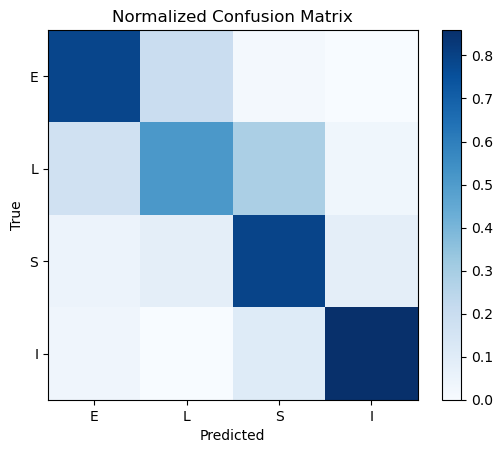

In [7]:
# Confusion matrix
conf_norm = conf.div(conf.sum(axis=1), axis=0)

plt.imshow(conf_norm.values, cmap="Blues")
plt.colorbar()

plt.xticks(range(len(classes)), classes)
plt.yticks(range(len(classes)), classes)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

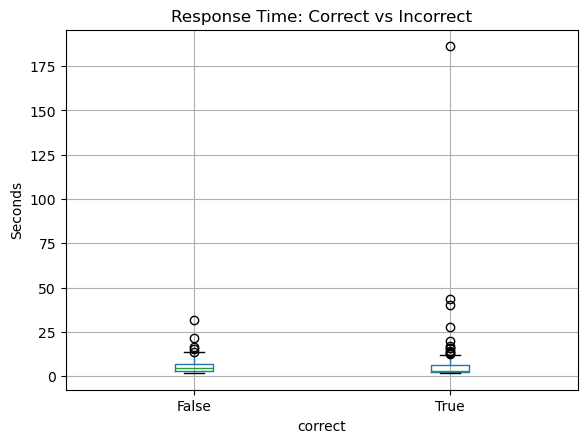

In [8]:
# Response time vs correctness
df["response_time"].describe()
df.boxplot(column="response_time", by="correct")
plt.title("Response Time: Correct vs Incorrect")
plt.suptitle("")
plt.ylabel("Seconds")
plt.show()

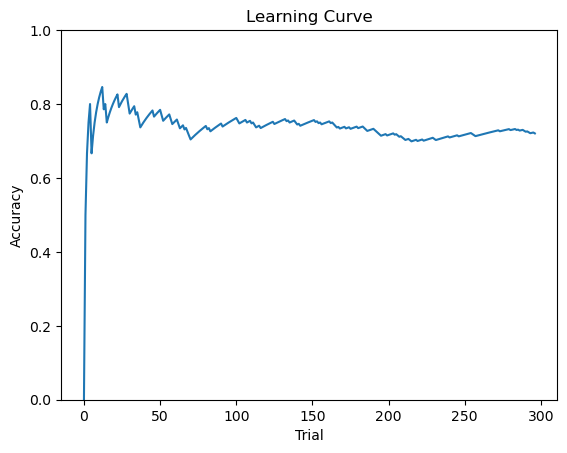

In [9]:
# Learning curve
df["running_acc"] = df["correct"].cumsum() / (np.arange(len(df)) + 1)

plt.plot(df["running_acc"])
plt.ylim(0, 1)
plt.title("Learning Curve")
plt.xlabel("Trial")
plt.ylabel("Accuracy")
plt.show()

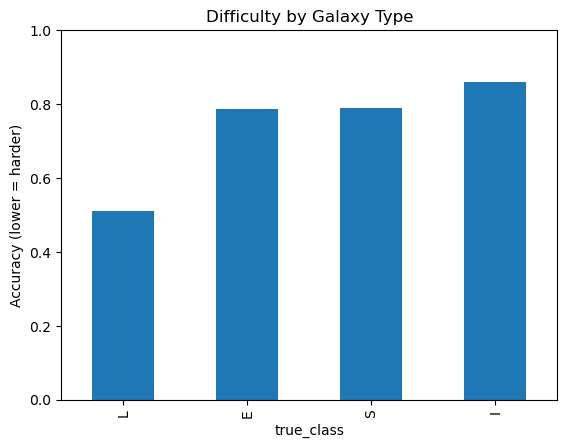

In [10]:
# Difficulty by accuracy
difficulty = df.groupby("true_class")["correct"].mean().sort_values()

difficulty.plot(kind="bar")
plt.title("Difficulty by Galaxy Type")
plt.ylabel("Accuracy (lower = harder)")
plt.ylim(0, 1)
plt.show()

In [11]:
# Confusion pairs
conf_pairs = df[df["correct"] == False].groupby(
    ["true_class", "user_class"]
).size().sort_values(ascending=False)

conf_pairs.head(10)

true_class  user_class
L           S             27
            E             16
E           L             11
I           S              9
S           L              5
            I              5
L           I              3
I           E              3
S           E              3
E           S              1
dtype: int64

In [12]:
# Session summary
print("=== SESSION SUMMARY ===")
print(f"Accuracy: {df['correct'].mean()*100:.2f}%")
print(f"Avg response time: {df['response_time'].mean():.2f}s")
print(f"Fastest response: {df['response_time'].min():.2f}s")
print(f"Slowest response: {df['response_time'].max():.2f}s")
print("\nClass performance:")
print(difficulty)

=== SESSION SUMMARY ===
Accuracy: 72.05%
Avg response time: 5.71s
Fastest response: 1.54s
Slowest response: 186.37s

Class performance:
true_class
L    0.510638
E    0.785714
S    0.790323
I    0.858824
Name: correct, dtype: float64


In [13]:
# Accuracy per user
import glob

files = glob.glob("/pscratch/sd/q/qshimp/VI_training/savefiles/*.csv")

summary = []

for f in files:
    d = pd.read_csv(f)
    summary.append({
        "file": f.split("/")[-1],
        "accuracy": d["correct"].mean(),
        "n": len(d)
    })

pd.DataFrame(summary)

,file,accuracy,n
0,QuillanIMR.csv,0.720539,297
1,Quillan_flagged.csv,0.000000,27
2,QuillanIMR_flagged.csv,0.000000,70
3,Quillan.csv,0.657407,108


In [14]:
# Flagged galaxies
flagged = pd.read_csv("/pscratch/sd/q/qshimp/VI_training/savefiles/Quillan_flagged.csv")
flagged

,ref_id,RA,DEC,true_class,your_class,path,correct,notes
0,977814,74.889540,-17.457688,L,S,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
1,203418,184.588544,21.646031,S,L,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
2,717583,19.588447,-60.870350,I,S,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
3,189306,169.826818,12.773767,E,L,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
4,67370,29.228008,-59.399904,I,S,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
5,251451,218.575800,24.412288,L,E,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
6,913656,118.486899,53.355430,S,L,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
7,840447,142.960034,9.209899,E,L,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
8,350687,83.632402,-30.896956,L,S,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
9,1362497,33.422953,0.208052,L,E,/pscratch/sd/q/qshimp/Cutouts/sga2020/Anchors/...,False,NaN
